In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('Data/data_preprocessing.csv', index_col='Date', parse_dates=True)
df.head()

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-01,0.0,24.12,66.46,26.87
1985-01-02,0.0,24.27,66.08,26.60
1985-01-03,0.1,25.02,61.42,22.44
1985-01-04,0.2,25.26,60.54,22.89
1985-01-05,0.0,25.05,59.92,24.88


In [3]:
# Sắp xếp và kiểm tra dữ liệu
df = df.sort_index()

# kiểm tra liên tục thời gian
print(df.index.to_series().diff().value_counts().head())

Date
1 days    12204
Name: count, dtype: int64


In [4]:
# Chọn biến đầu vào & mục tiêu
features = ['Precipitation', 'Relative Humidity', 'Wind Speed']
target = 'Temperature'

X = df[features]
y = df[target]

In [5]:
# Chia tập dữ liệu: 70% train, 15% validation, 15% test
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8543, 3)
y_train shape: (8543,)
X_val shape: (1830, 3)
y_val shape: (1830,)
X_test shape: (1832, 3)
y_test shape: (1832,)


In [7]:
# Chuẩn hóa dữ liệu
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

In [8]:
# Hàm tạo chuỗi dữ liệu > Dự đoán ngày tiếp theo
def create_sequences(X, y, time_step):
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_step):
        X_seq.append(X[i:i + time_step])
        y_seq.append(y[i + time_step])
        
    return np.array(X_seq), np.array(y_seq)

In [9]:
# Xác định time_step = 30 
time_step = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_step)
X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val_scaled, time_step)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, time_step)

In [10]:
# Khai báo thư viện
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

In [11]:
# Khởi tạo lớp LTCCell 
from keras.saving import register_keras_serializable

@register_keras_serializable()
class LTCCell(layers.Layer):
    def __init__(self, units, **kwargs):
        super(LTCCell, self).__init__(**kwargs)
        self.units = units
    # Khai báo state_size & output_size
    @property
    def state_size(self): # Kích thước trạng thái ẩn
        return self.units
    @property
    def output_size(self): # Kích thước đầu ra
        return self.units
    # Tạo các tham số (weights)
    def build(self, input_shape):
        input_dim = int(input_shape[-1])
# Trọng số cho input
        self.W = self.add_weight(
            shape=(input_dim, self.units),
            initializer='glorot_uniform',
            trainable=True,
            name='kernel_W'
        )
# Trọng số hồi quy
        self.U = self.add_weight(
            shape=(self.units, self.units),
            initializer='orthogonal',
            trainable=True,
            name='recurrent_kernel_U'
        )
# Bias
        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
            name='bias_b'
        )
# Tham số τ (time constant) 
# τ lớn → cập nhật chậm
# τ nhỏ → cập nhật nhanh
        self.tau = self.add_weight(
            shape=(self.units,),
            initializer='ones',
            trainable=True,
            name='time_constant_tau'
        )
# Hệ số khuếch đại
        self.gain = self.add_weight(
            shape=(self.units,),
            initializer='ones',
            trainable=True,
            name='gain'
        )
        super(LTCCell, self).build(input_shape)
        # Hàm cập nhật trạng thái (call)
    def call(self, inputs, states):
        prev_output = states[0] 
# Tính h = Wx + Uh + b
        h = tf.matmul(inputs, self.W) + tf.matmul(prev_output, self.U) + self.b
# Giới hạn τ để tránh giá trị quá lớn/nhỏ
        tau_clipped = tf.clip_by_value(self.tau, 0.1, 10.0)
# α = 1/τ
        alpha = 1.0 / tau_clipped
# Hàm kích hoạt
        activation = tf.tanh(self.gain * h)
# Công thức cập nhật động học liên tục
        output = (1 - alpha) * prev_output + alpha * activation
        return output, [output]

In [12]:
from tensorflow.keras.models import load_model
import os
import glob

# Tìm tất cả file .keras trong thư mục hiện tại và thư mục con
print("Đang tìm kiếm file model .keras...")
all_keras_files = glob.glob("**/*.keras", recursive=True)
print(f"\nCác file .keras tìm thấy ({len(all_keras_files)}):")
for f in all_keras_files:
    print(f"  - {f}")

# Mapping tên model với các pattern có thể có
model_patterns = {
    "cnn": ["*cnn*.keras", "*CNN*.keras"],
    "lstm": ["*lstm*.keras", "*LSTM*.keras"],
    "gru": ["*gru*.keras", "*GRU*.keras"],
    "lnn": ["*lnn*.keras", "*LNN*.keras", "*liquid*.keras"]
}

models = {}
found_models = {}

for model_name, patterns in model_patterns.items():
    for pattern in patterns:
        matching_files = glob.glob(pattern, recursive=False) + glob.glob(pattern, recursive=True)
        if matching_files:
            found_models[model_name] = matching_files[0]
            break

print(f"\n{'='*50}")
print("KẾT QUẢ TÌM KIẾM:")
print(f"{'='*50}")

# Kiểm tra xem có đủ model không
if len(found_models) < 4:
    print(f"⚠️  Chỉ tìm thấy {len(found_models)}/4 model:")
    for name, path in found_models.items():
        print(f"  ✓ {name.upper()}: {path}")
    missing = set(["cnn", "lstm", "gru", "lnn"]) - set(found_models.keys())
    print(f"\n❌ Thiếu các model: {', '.join([m.upper() for m in missing])}")
    print("\n💡 Bạn cần:")
    print("   1. Chạy các notebook huấn luyện (03.CNN_1D.ipynb, 04.GRU.ipynb,")
    print("      05.LSTM.ipynb, 06.LNN.ipynb) để tạo và lưu model")
    print("   2. Hoặc đặt các file .keras đã có vào thư mục hiện tại")
    raise FileNotFoundError(f"Thiếu {len(missing)} model. Cần huấn luyện và lưu model trước.")

# Load các model đã tìm thấy
print(f"✅ Tìm thấy đủ 4 model:")

# Load CNN
model_cnn = load_model(found_models["cnn"])
print(f"  ✓ CNN: {found_models['cnn']}")

# Load LSTM
model_lstm = load_model(found_models["lstm"])
print(f"  ✓ LSTM: {found_models['lstm']}")

# Load GRU
model_gru = load_model(found_models["gru"])
print(f"  ✓ GRU: {found_models['gru']}")

# Load LNN (cần custom_objects)
model_lnn = load_model(found_models["lnn"], custom_objects={"LTCCell": LTCCell})
print(f"  ✓ LNN: {found_models['lnn']}")

print(f"\n{'='*50}")
print("✅ Tất cả model đã được load thành công!")
print(f"{'='*50}")

Đang tìm kiếm file model .keras...

Các file .keras tìm thấy (5):
  - best_model_gru.keras
  - model_gru.keras
  - model_lnn.keras
  - model_lstm.keras
  - module_cnn_1d.keras

KẾT QUẢ TÌM KIẾM:
✅ Tìm thấy đủ 4 model:
  ✓ CNN: module_cnn_1d.keras
  ✓ LSTM: model_lstm.keras
  ✓ GRU: best_model_gru.keras
  ✓ LNN: model_lnn.keras

✅ Tất cả model đã được load thành công!


In [13]:
y_pred_cnn  = scaler_y.inverse_transform(model_cnn.predict(X_test_seq))
y_pred_lstm = scaler_y.inverse_transform(model_lstm.predict(X_test_seq))
y_pred_gru  = scaler_y.inverse_transform(model_gru.predict(X_test_seq))
y_pred_lnn  = scaler_y.inverse_transform(model_lnn.predict(X_test_seq))

y_test_original = scaler_y.inverse_transform(y_test_seq)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step   
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mse, rmse, mae, r2, mape

In [15]:
results = {}
results["CNN-1D"] = evaluate_model(y_test_original, y_pred_cnn)
results["LSTM"]   = evaluate_model(y_test_original, y_pred_lstm)
results["GRU"]    = evaluate_model(y_test_original, y_pred_gru)
results["LNN"]    = evaluate_model(y_test_original, y_pred_lnn)

In [16]:
comparison_df = pd.DataFrame(results, 
                             index=["MSE", "RMSE", "MAE", "R²", "MAPE (%)"]).T
comparison_df.round(4)

,MSE,RMSE,MAE,R²,MAPE (%)
CNN-1D,1.5101,1.2289,0.9388,0.4343,3.6211
LSTM,1.2891,1.1354,0.8816,0.5171,3.3467
GRU,1.0848,1.0415,0.7882,0.5936,3.0312
LNN,1.4089,1.1870,0.9220,0.4722,3.4930


<Axes: >

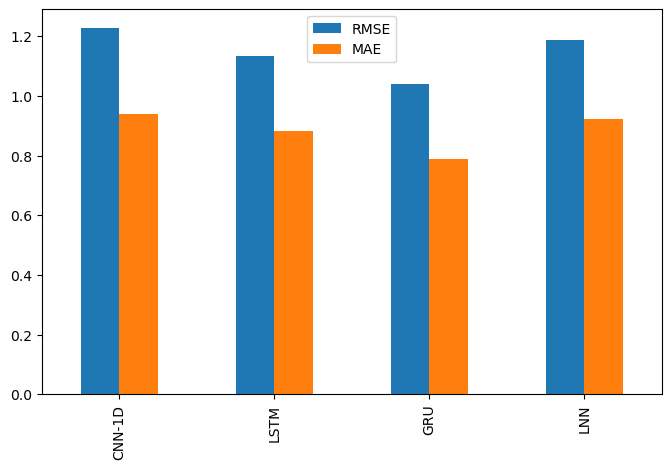

In [17]:
comparison_df[["RMSE", "MAE"]].plot(kind="bar", figsize=(8,5))

<Figure size 800x500 with 0 Axes>

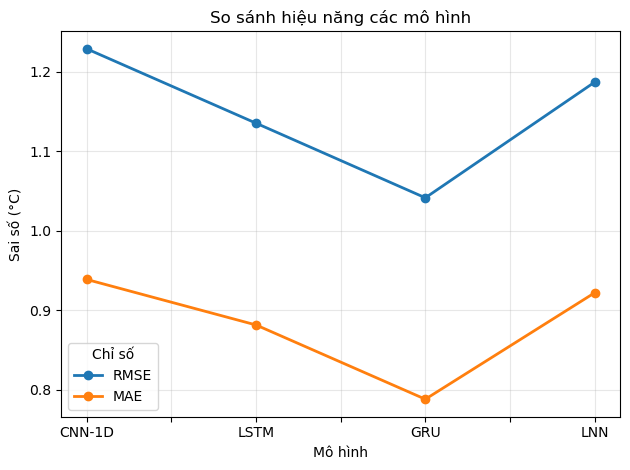

In [18]:
plt.figure(figsize=(8,5))

ax = comparison_df[["RMSE", "MAE"]].plot(
    marker="o",
    linewidth=2
)

plt.title("So sánh hiệu năng các mô hình")
plt.ylabel("Sai số (°C)")
plt.xlabel("Mô hình")
plt.xticks(rotation=0)
plt.legend(title="Chỉ số")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

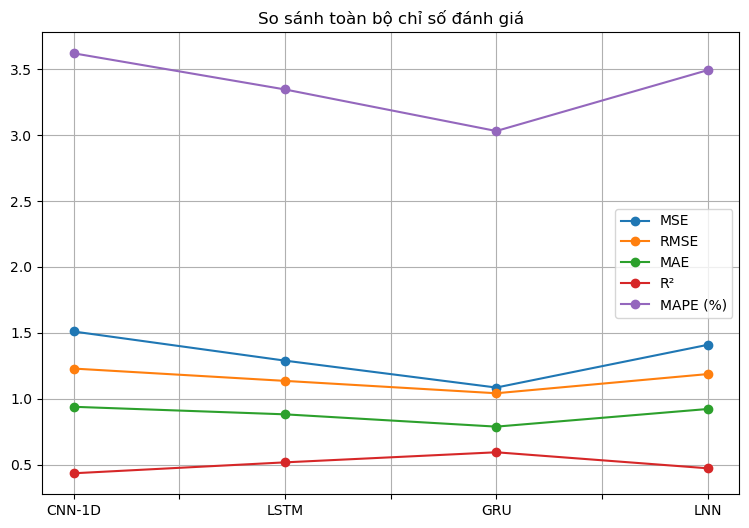

In [19]:
comparison_df.plot(
    kind="line",
    marker="o",
    figsize=(9,6)
)

plt.title("So sánh toàn bộ chỉ số đánh giá")
plt.grid(True)
plt.show()

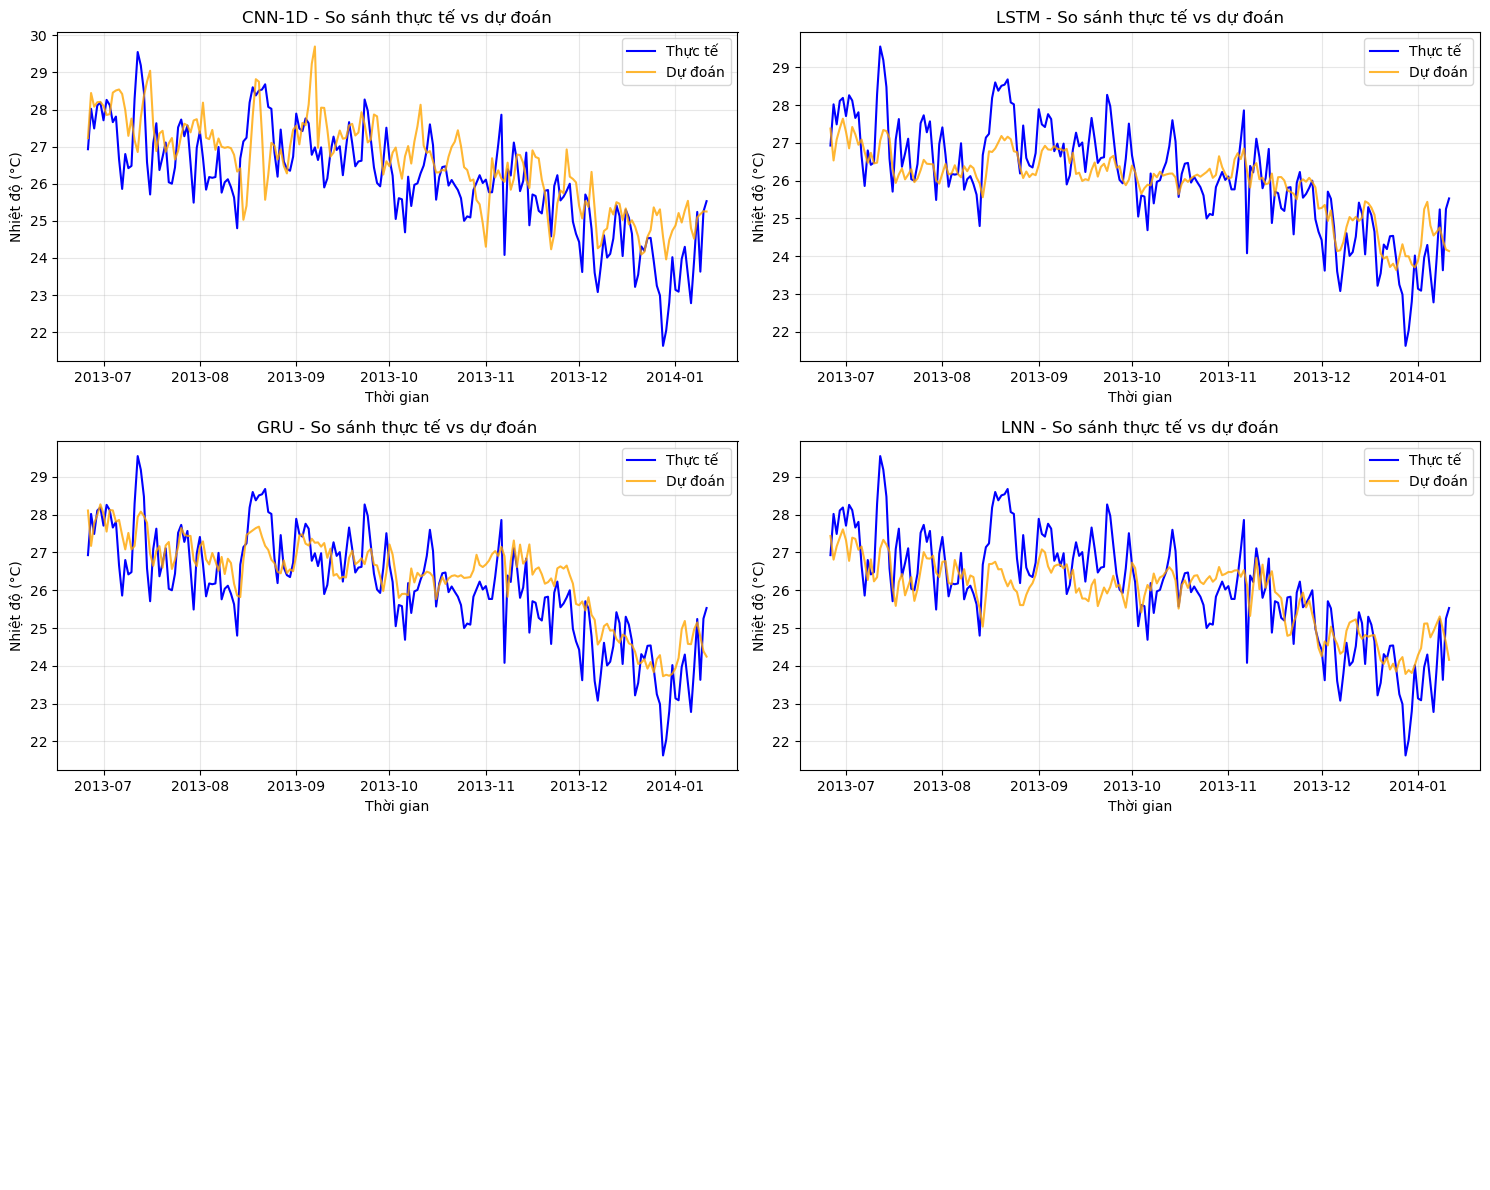

In [20]:
#### Trực quan hóa kết quả dự đoán - So sánh Actual vs Predicted

# Lấy index thời gian cho tập test
test_index = df.index[-len(y_test_seq):]

# Vẽ biểu đồ so sánh cho tất cả mô hình (200 ngày đầu tiên của test set)
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

models_data = [
    ("CNN-1D", y_pred_cnn),
    ("LSTM", y_pred_lstm),
    ("GRU", y_pred_gru),
    ("LNN", y_pred_lnn)
]

for idx, (name, y_pred) in enumerate(models_data):
    ax = axes[idx]
    ax.plot(test_index[:200], y_test_original[:200], label='Thực tế', color='blue', linewidth=1.5)
    ax.plot(test_index[:200], y_pred[:200], label='Dự đoán', color='orange', linewidth=1.5, alpha=0.8)
    ax.set_title(f'{name} - So sánh thực tế vs dự đoán', fontsize=12)
    ax.set_xlabel('Thời gian')
    ax.set_ylabel('Nhiệt độ (°C)')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Ẩn subplot thừa
axes[4].axis('off')
axes[5].axis('off')

plt.tight_layout()
plt.show()

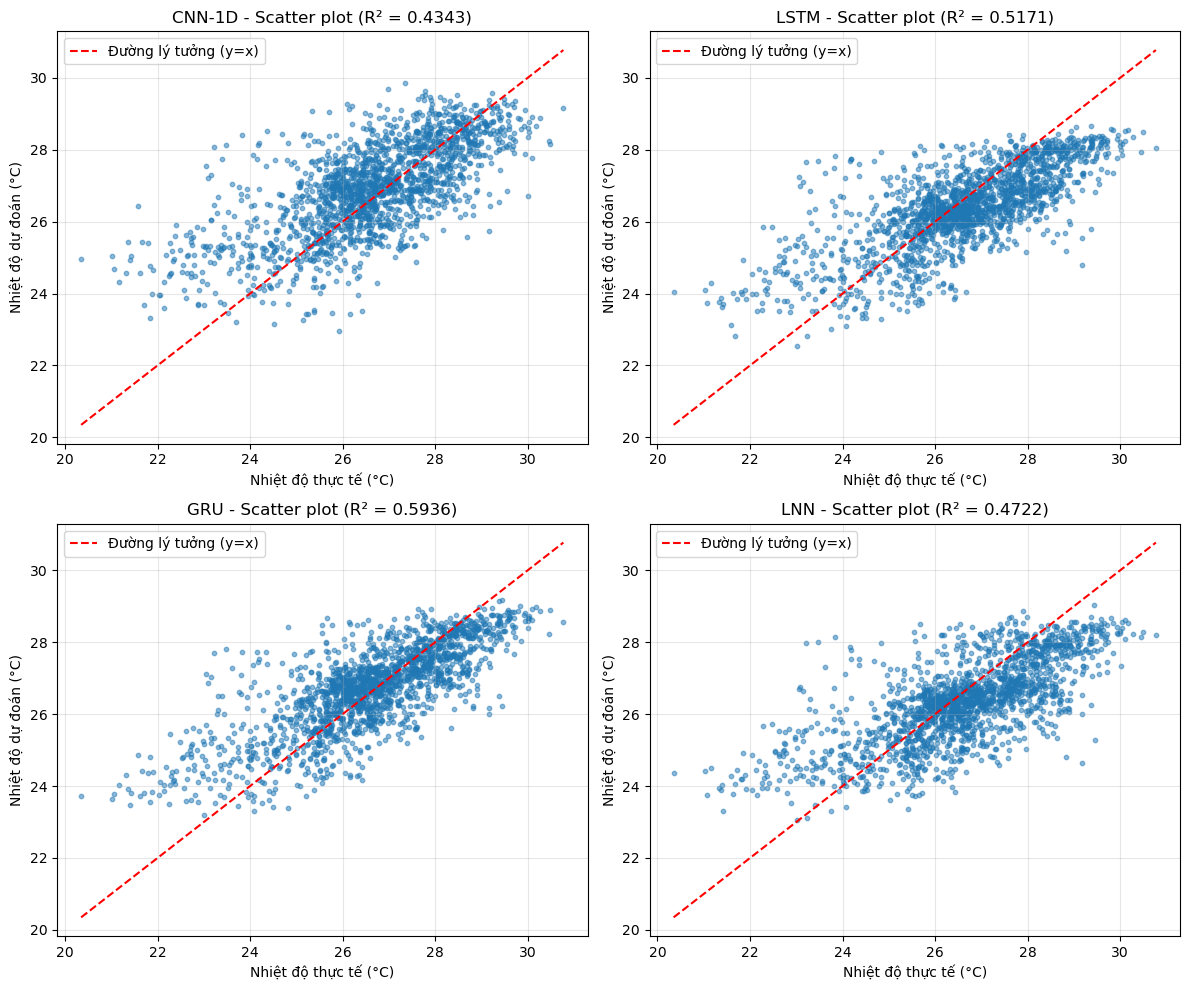

In [21]:
#### Scatter plot - Ma trận tương quan dự đoán
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# fig, axes = plt.subplots(1,3, figsize=(10,5))
axes = axes.flatten()

models_data = [
    ("CNN-1D", y_pred_cnn, results["CNN-1D"][3]),
    ("LSTM", y_pred_lstm, results["LSTM"][3]),
    ("GRU", y_pred_gru, results["GRU"][3]),
    ("LNN", y_pred_lnn, results["LNN"][3])
]

for idx, (name, y_pred, r2) in enumerate(models_data):
    ax = axes[idx]
    ax.scatter(y_test_original, y_pred, alpha=0.5, s=10)
    
    # Vẽ đường y=x
    min_val = min(y_test_original.min(), y_pred.min())
    max_val = max(y_test_original.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Đường lý tưởng (y=x)')
    
    ax.set_xlabel('Nhiệt độ thực tế (°C)')
    ax.set_ylabel('Nhiệt độ dự đoán (°C)')
    ax.set_title(f'{name} - Scatter plot (R² = {r2:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

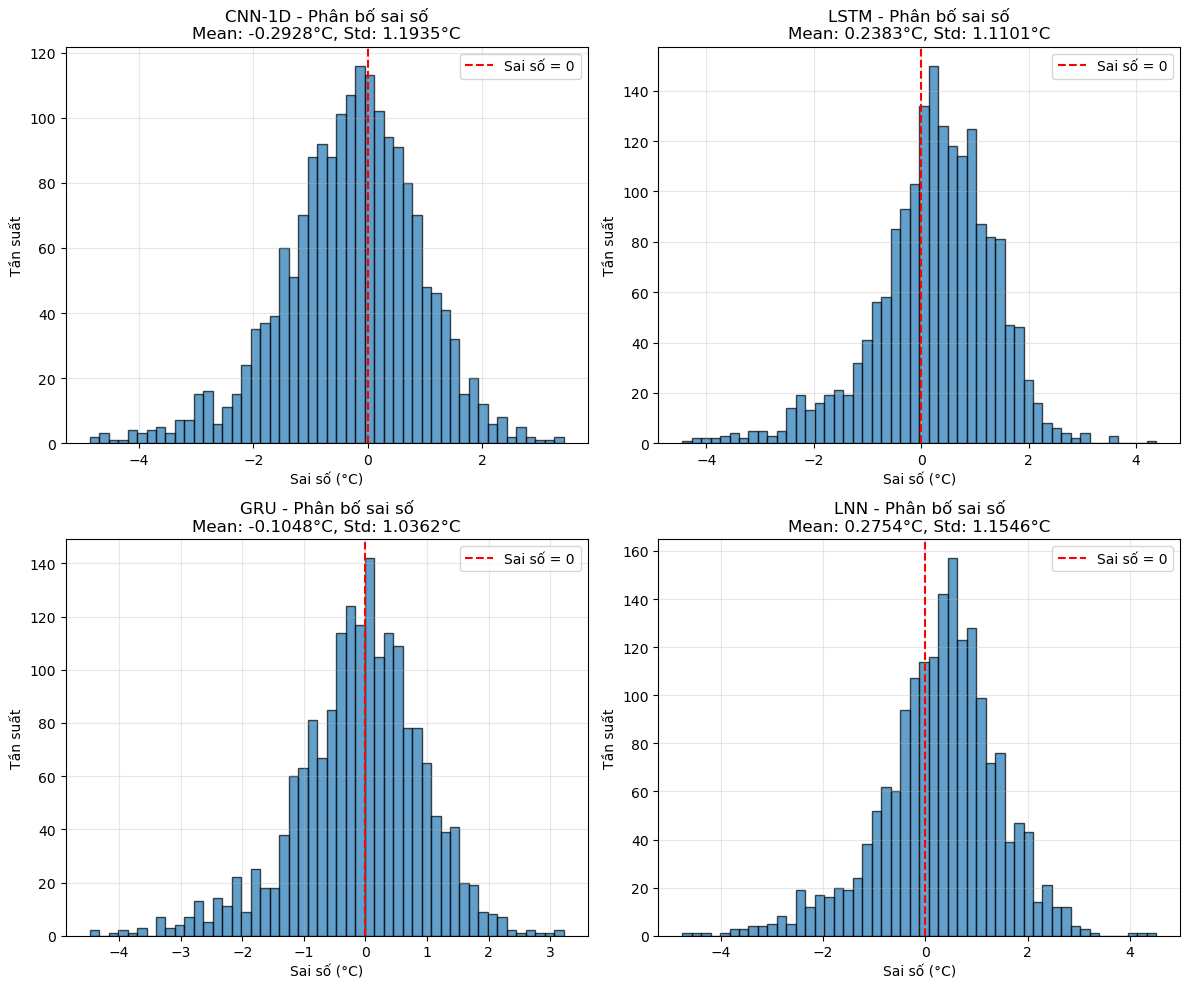

In [23]:
#### Phân tích sai số dự đoán (Residuals)
# fig, axes = plt.subplots(1,3, figsize=(10,5))
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

models_data = [
    ("CNN-1D", y_pred_cnn),
    ("LSTM", y_pred_lstm),
    ("GRU", y_pred_gru),
    ("LNN", y_pred_lnn)
]

for idx, (name, y_pred) in enumerate(models_data):
    ax = axes[idx]
    residuals = y_test_original - y_pred
    
    ax.hist(residuals.flatten(), bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='r', linestyle='--', label='Sai số = 0')
    ax.set_xlabel('Sai số (°C)')
    ax.set_ylabel('Tần suất')
    ax.set_title(f'{name} - Phân bố sai số\nMean: {residuals.mean():.4f}°C, Std: {residuals.std():.4f}°C')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

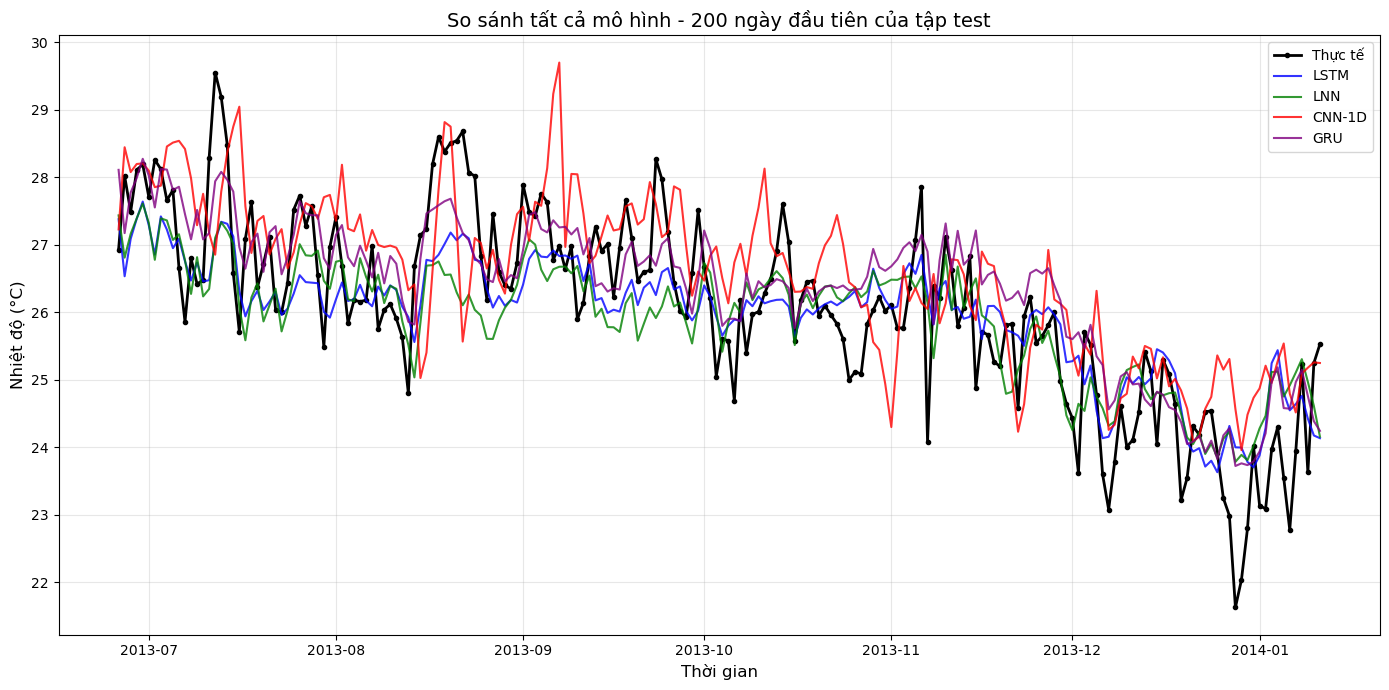


===== BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ =====
           MSE    RMSE     MAE      R² MAPE (%)
CNN-1D  1.5101  1.2289  0.9388  0.4343    3.62%
LSTM    1.2891  1.1354  0.8816  0.5171    3.35%
GRU     1.0848  1.0415  0.7882  0.5936    3.03%
LNN     1.4089  1.1870  0.9220  0.4722    3.49%


In [24]:
#### So sánh tất cả mô hình trên cùng một biểu đồ

plt.figure(figsize=(14, 7))

# Vẽ đường thực tế
plt.plot(test_index[:200], y_test_original[:200], label='Thực tế', color='black', linewidth=2, linestyle='-', marker='o', markersize=3)

# Vẽ đường dự đoán của từng mô hình
plt.plot(test_index[:200], y_pred_lstm[:200], label='LSTM', color='blue', linewidth=1.5, alpha=0.8)
plt.plot(test_index[:200], y_pred_lnn[:200], label='LNN', color='green', linewidth=1.5, alpha=0.8)
plt.plot(test_index[:200], y_pred_cnn[:200], label='CNN-1D', color='red', linewidth=1.5, alpha=0.8)
plt.plot(test_index[:200], y_pred_gru[:200], label='GRU', color='purple', linewidth=1.5, alpha=0.8)

plt.title('So sánh tất cả mô hình - 200 ngày đầu tiên của tập test', fontsize=14)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Nhiệt độ (°C)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# In bảng tổng hợp metrics
print("\n===== BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ =====")
comparison_df_display = comparison_df.copy()
comparison_df_display['MAPE (%)'] = comparison_df_display['MAPE (%)'].apply(lambda x: f"{x:.2f}%")
print(comparison_df_display.round(4))